In [1]:
import sys
sys.path.append('../')
import numpy as np
from matplotlib import pyplot as plt

from ventilation_layer import heat_transfer_coefficient as htc

# 無限平行面と2次元空間における放射熱伝達率を比較する
## 与条件の設定

表面温度  
面1：20.0 deg C  
面2：15.0 deg C  

In [2]:
# 表面温度の設定
theta_1 = 20.0
theta_2 = 15.0

放射率  
面1：0.9  
面2：0.1〜1.0, 0.1刻みの10通り

In [3]:
# 面1の放射率
eps1 = 0.9

# 面2の放射率
eps2 = np.arange(1, 11) / 10.0
print(eps2)

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


通気層の厚さ  
0.015m 〜 0.49m 0.01m刻み

In [4]:
# 有限平行平板の場合の有効放射率
# 通気層厚さをパラメータに設定する
l_d = np.arange(15, 50) / 1000.0
print(l_d)

[0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023 0.024 0.025 0.026
 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035 0.036 0.037 0.038
 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047 0.048 0.049]


通気層胴縁または垂木の間隔  
0.455 m

In [5]:
l_s = 0.455

## 有効放射率

In [6]:
# 無限平行平板の場合の有効放射率
infinite_emissivity = htc.get_e(eps1, eps2)
print(infinite_emissivity)

[0.0989011  0.19565217 0.29032258 0.38297872 0.47368421 0.5625
 0.64948454 0.73469388 0.81818182 0.9       ]


In [7]:
finite_emissivity = np.vectorize(htc.get_e)(method="two_dimension", eps1=eps1, eps2=eps2[np.newaxis, :], l_d=l_d[:, np.newaxis], l_s=l_s)
finite_emissivity

array([[0.09874017, 0.19502339, 0.28894022, 0.38057686, 0.47001534,
        0.55733382, 0.64260679, 0.72590531, 0.80729715, 0.88684705],
       [0.09872947, 0.19498164, 0.28884859, 0.3804179 , 0.46977291,
        0.55699298, 0.64215372, 0.72532722, 0.80658222, 0.88598436],
       [0.09871877, 0.19493991, 0.28875702, 0.38025909, 0.46953076,
        0.5566526 , 0.64170134, 0.72475011, 0.80586864, 0.88512344],
       [0.09870807, 0.1948982 , 0.28866553, 0.38010044, 0.46928889,
        0.55631268, 0.64124966, 0.724174  , 0.80515641, 0.88426431],
       [0.09869738, 0.19485652, 0.2885741 , 0.37994193, 0.4690473 ,
        0.55597321, 0.64079866, 0.72359888, 0.80444553, 0.88340695],
       [0.09868669, 0.19481486, 0.28848274, 0.37978358, 0.46880599,
        0.55563421, 0.64034837, 0.72302475, 0.803736  , 0.88255136],
       [0.09867601, 0.19477323, 0.28839146, 0.37962539, 0.46856497,
        0.55529567, 0.63989877, 0.72245161, 0.80302782, 0.88169756],
       [0.09866533, 0.19473162, 0.2883002

## 放射熱伝達率

In [8]:
# 放射熱伝達率の計算
infinite_rad_heat_transfer = [htc.get_h_rv(theta_1=theta_1, theta_2=theta_2, eps_eff=emissivity) for emissivity in infinite_emissivity]

finite_rad_heat_transfer = np.vectorize(htc.get_h_rv)(theta_1=theta_1, theta_2=theta_2, eps_eff=finite_emissivity)

## 計算結果の比較（X軸＝放射率）

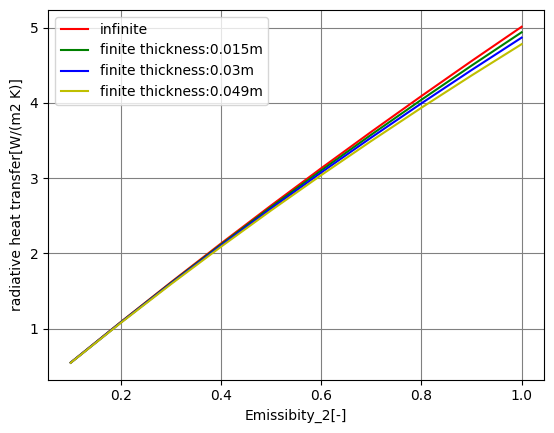

In [9]:
# グラフの描画（放射率別）
fig1 = plt.figure()
ax1 = fig1.subplots()

ax1.set_xlabel('Emissibity_2[-]')
ax1.set_ylabel('radiative heat transfer[W/(m2 K)]')

plt.grid(which='major', color='gray', linestyle='-')
plt.grid(which='minor', color='gray', linestyle='-')

plt.plot(eps2, infinite_rad_heat_transfer,linestyle='solid',
         color='r', label='infinite')
plt.plot(eps2, finite_rad_heat_transfer[0,:],linestyle='solid',
         color='g', label='finite thickness:0.015m')
plt.plot(eps2, finite_rad_heat_transfer[15,:],linestyle='solid',
         color='b', label='finite thickness:0.03m')
plt.plot(eps2, finite_rad_heat_transfer[34,:],linestyle='solid',
         color='y', label='finite thickness:0.049m')

plt.legend()
plt.show()

## 計算結果の比較（X軸=通気層厚さ）

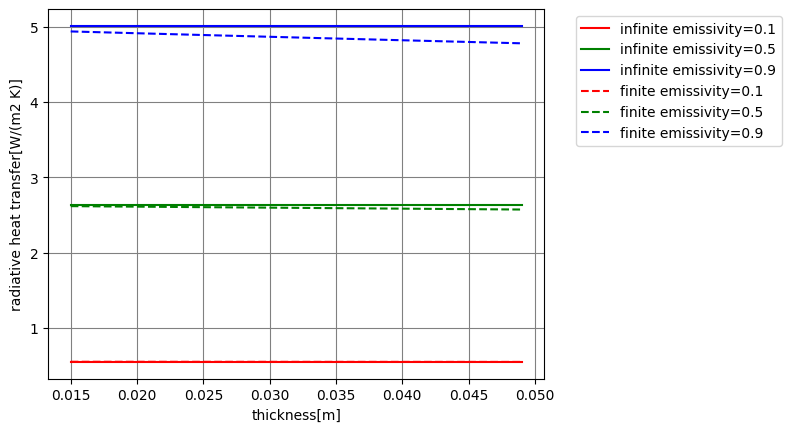

In [10]:
# グラフの描画（中空層厚さ別）
fig1 = plt.figure()
ax1 = fig1.subplots()

ax1.set_xlabel('thickness[m]')
ax1.set_ylabel('radiative heat transfer[W/(m2 K)]')

plt.grid(which='major', color='gray', linestyle='-')
plt.grid(which='minor', color='gray', linestyle='-')

plt.plot(l_d, np.full(35,infinite_rad_heat_transfer[0]),linestyle='solid',
         color='r', label='infinite emissivity=0.1')
plt.plot(l_d, np.full(35,infinite_rad_heat_transfer[4]),linestyle='solid',
         color='g', label='infinite emissivity=0.5')
plt.plot(l_d, np.full(35,infinite_rad_heat_transfer[9]),linestyle='solid',
         color='b', label='infinite emissivity=0.9')
plt.plot(l_d, finite_rad_heat_transfer[:,0],linestyle='dashed',
         color='r', label='finite emissivity=0.1')
plt.plot(l_d, finite_rad_heat_transfer[:,4],linestyle='dashed',
         color='g', label='finite emissivity=0.5')
plt.plot(l_d, finite_rad_heat_transfer[:,9],linestyle='dashed',
         color='b', label='finite emissivity=0.9')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

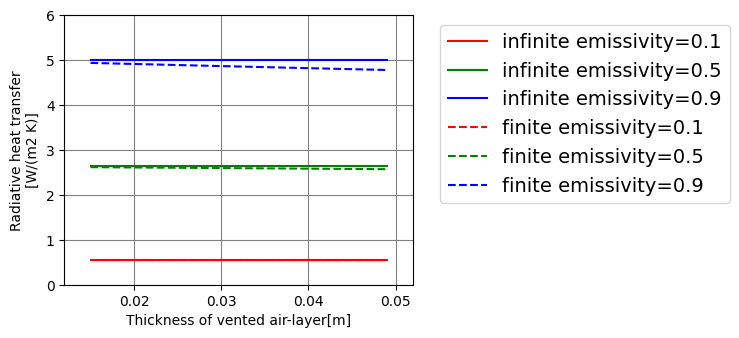

In [11]:
# グラフの描画（中空層厚さ別）

#fig1 = plt.figure()
#ax1 = fig1.subplots()
# グラフサイズを指定する　デフォルト：figsize=(6.4, 4.8)、小サイズ：figsize=(4.0, 3.5)
fig, ax1 = plt.subplots(figsize=(4.5, 3.5))
    
# フォントサイズを設定
plt.rcParams["font.size"] = 14

ax1.set_xlabel('Thickness of vented air-layer[m]')
ax1.set_ylabel('Radiative heat transfer\n[W/(m2 K)]')

plt.grid(which='major', color='gray', linestyle='-')
plt.grid(which='minor', color='gray', linestyle='-')

plt.plot(l_d, np.full(35,infinite_rad_heat_transfer[0]),linestyle='solid',
         color='r', label='infinite emissivity=0.1')
plt.plot(l_d, np.full(35,infinite_rad_heat_transfer[4]),linestyle='solid',
         color='g', label='infinite emissivity=0.5')
plt.plot(l_d, np.full(35,infinite_rad_heat_transfer[9]),linestyle='solid',
         color='b', label='infinite emissivity=0.9')
plt.plot(l_d, finite_rad_heat_transfer[:,0],linestyle='dashed',
         color='r', label='finite emissivity=0.1')
plt.plot(l_d, finite_rad_heat_transfer[:,4],linestyle='dashed',
         color='g', label='finite emissivity=0.5')
plt.plot(l_d, finite_rad_heat_transfer[:,9],linestyle='dashed',
         color='b', label='finite emissivity=0.9')

# 軸の描画範囲設定
ax1.set_xlim(0.012, 0.052)
ax1.set_ylim(0, 6)
    
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()